# Exploratory Data Analysis — Customer Churn

Goal: understand the data, confirm the class imbalance, and find features
that show a strong relationship with churn. These insights directly justify
the feature engineering and metric choices made later in `train_model.py`.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/telco_churn.csv")
df.shape

(7043, 21)

In [19]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## 1. Class Imbalance Check

This is the single most important check — it determines which metrics matter.

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


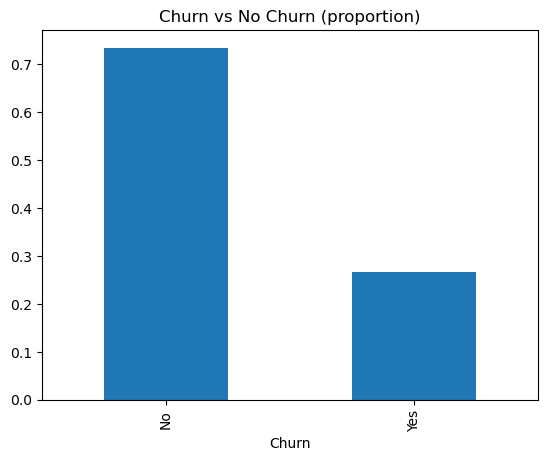

In [14]:
churn_rate = df["Churn"].value_counts(normalize=True)
print(churn_rate)
churn_rate.plot(kind="bar", title="Churn vs No Churn (proportion)")
plt.show()

**Insight:** ~26.5% of customers churned. This is an imbalanced classification
problem — accuracy alone would be misleading (a model predicting "No churn"
for everyone scores ~73% accuracy while being useless). This is why
`train_model.py` uses precision, recall, F1, and ROC-AUC instead.

## 2. Churn Rate by Contract Type

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


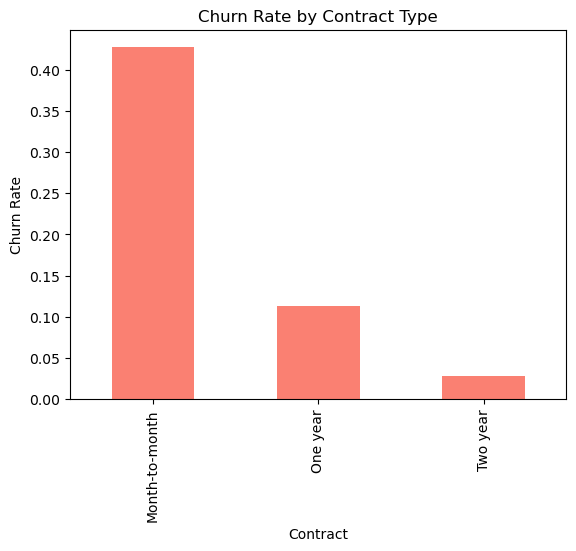

In [15]:
contract_churn = df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean())
print(contract_churn)
contract_churn.plot(kind="bar", title="Churn Rate by Contract Type", color="salmon")
plt.ylabel("Churn Rate")
plt.show()

**Insight:** Month-to-month customers churn at a dramatically higher rate
than One-year or Two-year customers. This is the single strongest signal
in the dataset and is confirmed later by the model's feature importance
(`Contract_One year` and `Contract_Two year` both have large negative
coefficients — i.e., having a longer contract strongly reduces churn risk).

## 3. Churn Rate by Internet Service

InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64


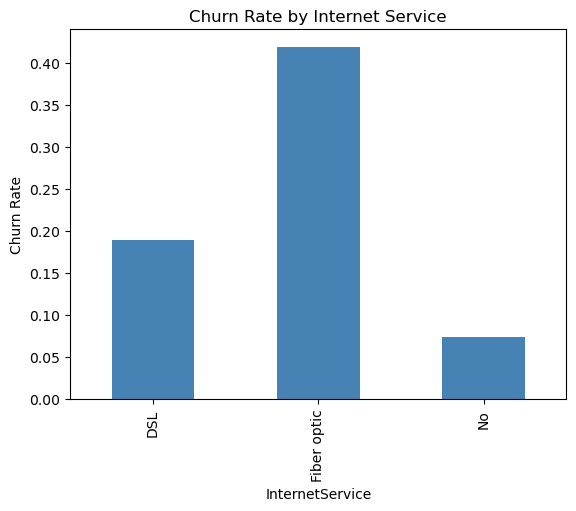

In [16]:
internet_churn = df.groupby("InternetService")["Churn"].apply(lambda x: (x == "Yes").mean())
print(internet_churn)
internet_churn.plot(kind="bar", title="Churn Rate by Internet Service", color="steelblue")
plt.ylabel("Churn Rate")
plt.show()

**Insight:** Fiber optic customers churn at a much higher rate than DSL or
no-internet customers. This could indicate pricing sensitivity (fiber is the
most expensive tier) or service quality issues — a great talking point for
"what would you investigate next" interview questions.

## 4. Tenure Distribution by Churn

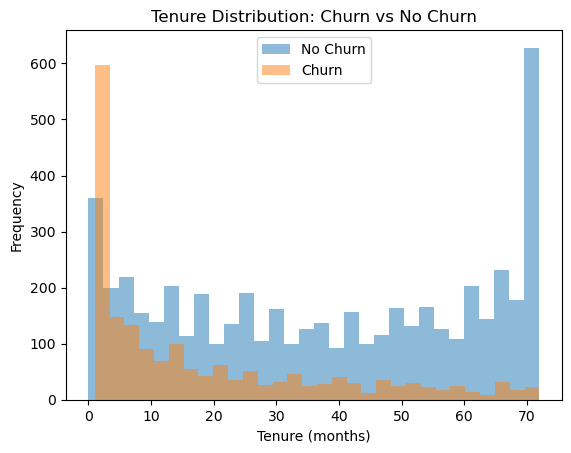

In [17]:
df[df["Churn"]=="No"]["tenure"].plot(kind="hist", alpha=0.5, label="No Churn", bins=30)
df[df["Churn"]=="Yes"]["tenure"].plot(kind="hist", alpha=0.5, label="Churn", bins=30)
plt.legend()
plt.title("Tenure Distribution: Churn vs No Churn")
plt.xlabel("Tenure (months)")
plt.show()

**Insight:** Churned customers are heavily concentrated in low-tenure
(0-12 months). This directly motivates the `tenure_group` feature created
in `data_preprocessing.py` — bucketing tenure into New/Medium/Long-term
makes this relationship explicit and interpretable.

## 5. Numeric Feature Correlation

In [18]:
import numpy as np

numeric_df = df.copy()
numeric_df["TotalCharges"] = pd.to_numeric(numeric_df["TotalCharges"].replace(" ", "0"))
numeric_df["Churn_binary"] = (numeric_df["Churn"] == "Yes").astype(int)

corr = numeric_df[["tenure", "MonthlyCharges", "TotalCharges", "Churn_binary"]].corr()
print(corr["Churn_binary"])

tenure           -0.352229
MonthlyCharges    0.193356
TotalCharges     -0.198324
Churn_binary      1.000000
Name: Churn_binary, dtype: float64


**Insight:** `tenure` has a meaningful negative correlation with churn
(longer tenure = less likely to churn), while `MonthlyCharges` has a positive
correlation (higher charges = more likely to churn). These align with the
feature importance results from the trained model.

## Summary of Key Insights (carried into feature engineering)

1. **Class imbalance (~26.5% churn)** → use precision/recall/F1/ROC-AUC, not accuracy; use `class_weight="balanced"`.
2. **Contract type is the strongest churn driver** → Month-to-month customers are highest risk.
3. **Fiber optic customers churn more** → possible pricing/service quality issue worth flagging to product/pricing teams.
4. **Low-tenure customers churn more** → motivates the `tenure_group` feature.
5. **Higher MonthlyCharges correlates with churn** → motivates the `avg_monthly_spend` feature to capture lifetime spending patterns.